<a href="https://colab.research.google.com/github/Gcarmnonapy7/computer-vision-camera/blob/main/movies_cluesterization_%26crowd_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



+----------------------+ | 1️⃣ Input Data | | - TMDb metadata | | - Box office data | | - Holiday/weekend | +----------+-----------+ | v +----------------------+ | 2️⃣ Data Cleaning | | - Parse genres/keywords| | - Fill missing values | | - Log-transform nums | | - One-hot categories | +----------+-----------+ | v +----------------------+ | 3️⃣ Feature Engineering | | - Genre strength | | - Keyword strength | | - Budget / revenue | | - Historical trends | +----------+-----------+ | v +----------------------+ | 4️⃣ Movie Similarity / Clustering | | - Cluster movies by features | | - Cosine similarity for keywords | | - Output: cluster label per movie | +----------+-----------+ | v +----------------------+ | 5️⃣ ML Crowd Prediction | | - Input: features + cluster | | - Target: total predicted crowd | | - Output: predicted total audience| +----------+-----------+ | v +----------------------+ | 6️⃣ Weekly Distribution | | - Split total predicted crowd per week | | - Adjust for holidays, weekends | | - Output: weekly predicted attendance | +----------+-----------+ | v +----------------------+ | 7️⃣ Cinema & Room Assignment | | - Simulate cinemas & rooms | | - Assign movies to rooms based on weekly attendance | | - Respect room capacities | | - Output: schedule per cinema/week | +----------+-----------+ | v +----------------------+ | 8️⃣ Output / Team Consumption | | - Export Excel / CSV / JSON | | - Columns: Movie, Cinema, Room,schedule time, Week, Predicted Crowd | +----------+-----------+ | v +----------------------+ +----------------------+


In [159]:
!pip install -q optuna

In [160]:
# import depedencies
import json
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
import kagglehub
import os
path_tmdb = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
path_movie_box = kagglehub.dataset_download("aditya126/movies-box-office-dataset-2000-2024")

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Using Colab cache for faster access to the 'movies-box-office-dataset-2000-2024' dataset.


In [162]:
print(os.listdir(path_tmdb))
print(os.listdir(path_movie_box))

['tmdb_5000_movies.csv', 'tmdb_5000_credits.csv']
['enhanced_box_office_data(2000-2024)u.csv']


In [163]:
#Import datasets
tmdb = pd.read_csv(os.path.join(path_tmdb,'tmdb_5000_movies.csv'))
box = pd.read_csv(os.path.join(path_movie_box,'enhanced_box_office_data(2000-2024)u.csv'))

Predicted Crowd Week w=∑similarityi​∑(similarityi​×crowdi,w​)​

In [164]:
print(tmdb.shape)
print(box.shape)

(4803, 20)
(5000, 13)


In [165]:
box.info(
    verbose=True,
    show_counts=True
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  5000 non-null   int64  
 1   Release Group         5000 non-null   object 
 2   $Worldwide            5000 non-null   float64
 3   $Domestic             5000 non-null   float64
 4   Domestic %            5000 non-null   float64
 5   $Foreign              5000 non-null   float64
 6   Foreign %             5000 non-null   float64
 7   Year                  5000 non-null   int64  
 8   Genres                4822 non-null   object 
 9   Rating                4830 non-null   object 
 10  Vote_Count            4830 non-null   float64
 11  Original_Language     4830 non-null   object 
 12  Production_Countries  4800 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 507.9+ KB


In [166]:
tmdb.info(
    verbose=True,
    show_counts=True
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [167]:
def clean_keywords(column_keywords):

    if column_keywords is None or (isinstance(column_keywords, float) and pd.isna(column_keywords)):
        return []

    if isinstance(column_keywords, str):
        try:
            column_keywords = json.loads(column_keywords)
        except (json.JSONDecodeError, TypeError):
            return []

    if isinstance(column_keywords, list):
        return [item['name'] if isinstance(item, dict) else str(item) for item in column_keywords]

    return []

tmdb['keywords'] = tmdb['keywords'].apply(clean_keywords)

In [168]:
tmdb['keywords']

,keywords
0,"[culture clash, future, space war, space colon..."
1,"[ocean, drug abuse, exotic island, east india ..."
2,"[spy, based on novel, secret agent, sequel, mi..."
3,"[dc comics, crime fighter, terrorist, secret i..."
4,"[based on novel, mars, medallion, space travel..."
...,...
4798,"[united states–mexico barrier, legs, arms, pap..."
4799,[]
4800,"[date, love at first sight, narration, investi..."
4801,[]


In [169]:
exploded_keywords = tmdb.explode('keywords')

words_freq = (
    exploded_keywords
    .groupby('keywords')
    ['revenue']
    .mean()
)

tmdb['keyword_strength'] = tmdb['keywords'].apply(
    lambda keywords: np.median([words_freq[word] for word in keywords]) if len(keywords) > 0 else 0
)

In [170]:
tmdb['keyword_strength'].describe()

,keyword_strength
count,4.803000e+03
mean,8.838494e+07
std,7.767139e+07
min,0.000000e+00
25%,4.317629e+07
50%,7.316093e+07
75%,1.151591e+08
max,8.772448e+08


In [171]:
columns_to_rename_box_df = {'Release Group': 'title','$Worldwide':'worldwide_gross','Rating' : 'rating','Production_Countries' : 'countries','Original_Language':'language', 'Domestic':'contry_view'}

In [172]:
box.rename(columns=columns_to_rename_box_df,inplace=True) # title and total crowd around the world

In [173]:
DROP_COLUMNS_TMDB = {
    'overview',
    'original_title',
    'production_companies',
    'production_countries',
    'homepage',
    'status',
    'tagline',
    'spoken_languages',
    'original_language'
}

tmdb = tmdb.drop(columns=DROP_COLUMNS_TMDB)

In [174]:
def clean_genres(col):
  if pd.isna(col) or col == '':
    return ''

  genres = json.loads(col)

  return ' '.join([g['name'].replace(' ','_').lower() for g in genres])

tmdb['genres'] = tmdb['genres'].apply(clean_genres)
tmdb['release_year'] = pd.to_datetime(tmdb['release_date']).dt.year


In [175]:
tmdb['genres_list'] = tmdb['genres'].apply(lambda x : x.split())
genre_exploded = tmdb.explode('genres_list')
genre_counts = genre_exploded['genres_list'].value_counts()
genre_avg_revenue = (
    genre_exploded
    .groupby('genres_list')
    ['revenue'].mean())

tmdb['genre_revenue_strength'] = tmdb['genres_list'].apply(lambda genres : np.mean([genre_avg_revenue[gen] for gen in genres] ) if len(genres) > 0 else 0)

In [176]:
display(genre_avg_revenue.sort_values(ascending=False).head(15))

print("\nSummary of Genre Revenue Strength:")
display(tmdb['genre_revenue_strength'].describe())

,revenue
genres_list,
animation,2.256930e+08
adventure,2.086602e+08
fantasy,1.933542e+08
family,1.623455e+08
science_fiction,1.524565e+08
action,1.412131e+08
war,8.415587e+07
thriller,8.104429e+07
mystery,7.830093e+07



Summary of Genre Revenue Strength:


,genre_revenue_strength
count,4.803000e+03
mean,8.753455e+07
std,4.053494e+07
min,0.000000e+00
25%,6.113604e+07
50%,7.128950e+07
75%,1.111287e+08
max,2.256930e+08


In [177]:
# Ensure tmdb is a proper copy to avoid SettingWithCopyWarning
tmdb = tmdb.copy()

# Fill 0 budgets with the median of their genre group
tmdb['budget'] = tmdb.groupby('genres')['budget'].transform(
    lambda x: x.replace(0, x.median())
)

# Fallback: For rows that are still 0 (groups where all budgets were 0), use the global median
global_median_budget = tmdb[tmdb['budget'] > 0]['budget'].median()
tmdb.loc[tmdb['budget'] == 0, 'budget'] = global_median_budget

print(f"Rows with 0 budget remaining: {len(tmdb[tmdb['budget'] == 0])}")
print(f"Global median used for fallback: {global_median_budget}")

Rows with 0 budget remaining: 0
Global median used for fallback: 18000000.0


In [178]:
tmdb = tmdb[tmdb['genres_list'].apply(len) > 0]

In [179]:
tmdb[['genres_list','genre_revenue_strength']]

,genres_list,genre_revenue_strength
0,"[action, adventure, fantasy, science_fiction]",1.739210e+08
1,"[adventure, fantasy, action]",1.810758e+08
2,"[action, adventure, crime]",1.386747e+08
3,"[action, crime, drama, thriller]",8.513107e+07
4,"[action, adventure, science_fiction]",1.674433e+08
...,...,...
4797,"[foreign, thriller]",4.070447e+07
4798,"[action, crime, thriller]",9.613602e+07
4799,"[comedy, romance]",6.564595e+07
4800,"[comedy, drama, romance, tv_movie]",4.585203e+07


In [180]:
print(len(tmdb[tmdb['genres_list'].apply(len) == 0]))# verify columns without genre

0


In [181]:
columns_to_log = ['revenue','budget','vote_count','keyword_strength']

def transform_log1p(data,columns_to_log):
  valid_columns = [col for col in columns_to_log if col in data.columns]
  data[valid_columns] = np.log1p(data[valid_columns])
  return data
tmdb_log1p = transform_log1p(tmdb,columns_to_log)

In [182]:
cols_to_check = ['budget', 'revenue', 'vote_count', 'keyword_strength']
tmdb_model = tmdb_log1p[(tmdb_log1p[cols_to_check] > 0).all(axis=1)].copy()

In [183]:
print(tmdb_log1p.shape)
print(tmdb_model.shape)

(4775, 15)
(3270, 15)


In [184]:
tmdb_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3270 entries, 0 to 4798
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   budget                  3270 non-null   float64
 1   genres                  3270 non-null   object 
 2   id                      3270 non-null   int64  
 3   keywords                3270 non-null   object 
 4   popularity              3270 non-null   float64
 5   release_date            3270 non-null   object 
 6   revenue                 3270 non-null   float64
 7   runtime                 3270 non-null   float64
 8   title                   3270 non-null   object 
 9   vote_average            3270 non-null   float64
 10  vote_count              3270 non-null   float64
 11  keyword_strength        3270 non-null   float64
 12  release_year            3270 non-null   float64
 13  genres_list             3270 non-null   object 
 14  genre_revenue_strength  3270 non-null   float

In [185]:
bad_words = {
    # Generic crime / vague
    'murder','violence','death','investigation','escape','rescue',
    'money','lawyer','doctor','teacher','journalist','writer',
    'hospital','police','detective','criminal','sheriff',
    'flashback','car_crash','chase','car_chase','shootout',
    # Emotional / relationship noise
    'relationship','new_love','jealousy','divorce',
    'wife_husband_relationship','parents_kids_relationship',
    'mother_daughter_relationship','sister_sister_relationship',
    'loss_of_father','funeral','party','single',
    # Sexual / rating-driven
    'sex','nudity','female_nudity','male_nudity',
    'rape','prostitute','adultery','extramarital_affair',
    # Location-based
    'paris','new_york_city','california','usa',
    # Weak generic
    'drug','drug_dealer','alcohol','alcoholic',
    'blackmail','neighbor','hotel',
    # Production noise
   'independent_film','found_footage', 'flipping coin', ' north carolinam',
   ' nosferatu', ' strange noise', 'Γη', '卧底肥妈', '绝地奶霸', '超级妈妈',
    '3d','imax','woman_director',
    'family','friends','friendship','marriage',
    'father_son_relationship','brother_sister_relationship',
    'brother_brother_relationship','daughter','best_friend',
    'love',"love_of_one's_life",'suicide','gay','black_people','torture','marijuana','killer',
    'secret','faith','obsession','dream','hero','author',
    'new_york','england','san_francisco','los_angeles','island','forest',
    'fight','battle','mission','explosion','army','government','fire','aftercreditsstinger','london_england','dying_and_death','kidnapping'
}

def clean_keywords(keywords_list):
    cleaned = []
    for kw in keywords_list:
        kw_clean = kw.replace(' ','_').strip()
        if kw_clean not in bad_words:
            cleaned.append(kw_clean)
    return cleaned

# 1. Create keywords_clean first
tmdb_model['keywords_clean'] = tmdb_model['keywords'].apply(clean_keywords)

# 2. Now calculate frequencies using the newly created column
all_keywords = [
    kw for sublist in tmdb_model['keywords_clean']
    for kw in sublist
]
counted_words = Counter(all_keywords)

most_common_list = {
    word for word , count in counted_words.items()
    if 20 <= count <= 300
}

def filter_most_common_words(keywords_list):
    return [kw for kw in keywords_list if kw in most_common_list]

# 3. Create keywords_final
tmdb_model['keywords_final'] = tmdb_model['keywords_clean'].apply(filter_most_common_words)

for idx,count in counted_words.items():
  if 20 <= count <= 300:
    print(f'{idx} : {count}')

future : 41
space : 25
alien : 70
soldier : 30
ship : 24
spy : 35
based_on_novel : 179
secret_agent : 24
sequel : 89
dc_comics : 20
terrorist : 29
secret_identity : 33
superhero : 63
princess : 24
amnesia : 21
marvel_comic : 34
revenge : 94
hostage : 26
magic : 50
musical : 75
animation : 26
duringcreditsstinger : 278
based_on_comic_book : 51
witch : 35
saving_the_world : 34
undercover : 37
monster : 33
alien_invasion : 21
time_travel : 39
corruption : 45
based_on_young_adult_novel : 39
dinosaur : 20
war : 36
scientist : 32
suspense : 61
mutant : 23
robot : 23
artificial_intelligence : 25
dystopia : 132
deception : 25
motorcycle : 20
comedy : 23
college : 24
post-apocalyptic : 28
zombie : 32
1970s : 28
infidelity : 24
based_on_video_game : 26
romantic_comedy : 27
holiday : 29
ghost : 27
christmas : 27
remake : 47
based_on_true_story : 45
cia : 41
world_war_ii : 51
airplane : 45
teenager : 74
martial_arts : 44
rivalry : 26
survival : 39
conspiracy : 33
vampire : 36
usa_president : 29
ch

In [186]:
tmdb_model['keywords_final']

,keywords_final
0,"[future, space, alien, soldier]"
1,[ship]
2,"[spy, based_on_novel, secret_agent, sequel]"
3,"[dc_comics, terrorist, secret_identity, superh..."
4,"[based_on_novel, princess, alien]"
...,...
4775,[]
4788,[]
4792,[based_on_novel]
4796,[time_travel]


In [187]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb_genres = MultiLabelBinarizer()
mlb_keywords = MultiLabelBinarizer()
genres_encoded = mlb_genres.fit_transform(tmdb_model['genres_list'])
keywords_encoded = mlb_keywords.fit_transform(tmdb_model['keywords_final'])

In [188]:
genres_encoded_df = pd.DataFrame(
    genres_encoded,
    columns=mlb_genres.classes_,
    index=tmdb_model.index
)

keywords_encoded_df = pd.DataFrame(
    keywords_encoded,
    columns=mlb_keywords.classes_,
    index=tmdb_model.index
)

keywords_encoded_df.columns = ['kw_' + word.strip() for word in keywords_encoded_df.columns]

In [189]:
genres_encoded_df.columns

Index(['action', 'adventure', 'animation', 'comedy', 'crime', 'documentary',
       'drama', 'family', 'fantasy', 'foreign', 'history', 'horror', 'music',
       'mystery', 'romance', 'science_fiction', 'thriller', 'war', 'western'],
      dtype='object')

In [190]:
master_df = pd.concat([tmdb_model, genres_encoded_df, keywords_encoded_df], axis=1)

In [191]:
master_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'popularity', 'release_date',
       'revenue', 'runtime', 'title', 'vote_average',
       ...
       'kw_terrorist', 'kw_time_travel', 'kw_undercover', 'kw_usa_president',
       'kw_vampire', 'kw_war', 'kw_wedding', 'kw_witch', 'kw_world_war_ii',
       'kw_zombie'],
      dtype='object', length=134)

In [192]:
print(genres_encoded)

[[1 1 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 0 0]
 [1 0 0 ... 1 0 0]]


In [193]:
print(keywords_encoded)

[[0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [194]:
print(genres_encoded.shape)
print(keywords_encoded.shape)

(3270, 19)
(3270, 98)


In [195]:
# Fix: Pass a single list of arrays to hstack and remove the extra tuple nesting
x_similarity = np.hstack([genres_encoded * 5, keywords_encoded])

In [196]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(x_similarity)

In [197]:
cosine_sim.shape

(3270, 3270)

In [198]:
cosine_sim.diagonal()[:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [199]:
print(f'Mean similarity :{np.mean(cosine_sim)}')
print("Max similarity:", np.max(cosine_sim))
print("Min similarity:", np.min(cosine_sim))

# === OK metrics for the case ===

Mean similarity :0.2427316630543165
Max similarity: 1.0000000000000004
Min similarity: 0.0


In [200]:
def show_similarity(movie_idx,top_n=10):
  similar_scores = list(enumerate(cosine_sim[movie_idx]))

  similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)

  similar_scores = similar_scores[1:top_n+1] # pick the most common movies

  print(f'Movie choosen : {tmdb_model.iloc[movie_idx]['title']}')

  print('Top similar movies :')

  for idx,score in similar_scores:
    print(f'{tmdb_model.iloc[idx]["title"]} : {score}')



show_similarity(movie_idx=np.random.randint(1000),top_n=10)


Movie choosen : The Break-Up
Top similar movies :
It's Complicated : 0.9999999999999998
Just Go with It : 0.9999999999999998
What Women Want : 0.9999999999999998
You, Me and Dupree : 0.9999999999999998
The Break-Up : 0.9999999999999998
Mr. Deeds : 0.9999999999999998
How to Lose a Guy in 10 Days : 0.9999999999999998
Bridget Jones: The Edge of Reason : 0.9999999999999998
Monster-in-Law : 0.9999999999999998
Boomerang : 0.9999999999999998


In [201]:
import optuna
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score # unsupervised learning metrics
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

def objective(trial):
    n_clusters = trial.suggest_int('n_clusters', 5, 15)
    tol= trial.suggest_float('tol', 0.001, 0.1)
    verbose= trial.suggest_int('verbose', 0, 2)
    max_iter= trial.suggest_int('max_iter', 100, 500)
    genre_weight = trial.suggest_int('genre_weight',1,5)
    pca_components = trial.suggest_int('pca_components',10,50)

    # Build features
    x = np.hstack([
        genres_encoded * genre_weight,
        keywords_encoded
    ])

    x_norm = normalize(x)

    # Reducing dims (PCA)

    pca = PCA(n_components=pca_components)
    x_reduced = pca.fit_transform(x_norm)

    # Kmeans
    kmeans = KMeans(n_clusters=n_clusters,
                    verbose=verbose,
                    max_iter=max_iter,
                    tol=tol, random_state=42)
    labels = kmeans.fit_predict(x_reduced)

    score = silhouette_score(x_reduced, labels)

    return score


In [202]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print('Number of finished trials:', len(study.trials))
print('Best trial:', study.best_trial.params)
print('Best value:', study.best_trial.value)

[I 2026-02-26 20:14:18,657] A new study created in memory with name: no-name-416cb255-a3db-48b4-a37d-f4a0fdb65024
[I 2026-02-26 20:14:19,123] Trial 0 finished with value: 0.2991925141712023 and parameters: {'n_clusters': 15, 'tol': 0.09490955647674623, 'verbose': 0, 'max_iter': 328, 'genre_weight': 3, 'pca_components': 12}. Best is trial 0 with value: 0.2991925141712023.


Initialization complete
Iteration 0, inertia 1909.8918703188992.
Iteration 1, inertia 1318.283384485674.
Iteration 2, inertia 1294.6367762861853.
Iteration 3, inertia 1285.6598046709382.
Iteration 4, inertia 1281.2402186164745.
Iteration 5, inertia 1279.6598614106424.
Iteration 6, inertia 1279.3954518897388.
Iteration 7, inertia 1279.0370607364848.
Iteration 8, inertia 1278.1798031145256.
Iteration 9, inertia 1274.941394957792.
Iteration 10, inertia 1274.4284060411564.
Iteration 11, inertia 1274.2666211948285.
Converged at iteration 11: center shift 4.486866515267569e-05 within tolerance 5.479343922041508e-05.


[I 2026-02-26 20:14:19,516] Trial 1 finished with value: 0.18417665405501218 and parameters: {'n_clusters': 8, 'tol': 0.0025879574166480773, 'verbose': 1, 'max_iter': 125, 'genre_weight': 2, 'pca_components': 34}. Best is trial 0 with value: 0.2991925141712023.


Initialization complete
Iteration 0, inertia 1287.1259704074116.
Iteration 1, inertia 970.8810431549447.
Iteration 2, inertia 954.0060504934819.
Iteration 3, inertia 951.2791467007618.
Iteration 4, inertia 950.9525748987764.
Converged at iteration 4: center shift 0.0004975902820047338 within tolerance 0.001985013208214721.


[I 2026-02-26 20:14:20,022] Trial 2 finished with value: 0.25057965601198295 and parameters: {'n_clusters': 15, 'tol': 0.08517248546793754, 'verbose': 1, 'max_iter': 278, 'genre_weight': 5, 'pca_components': 32}. Best is trial 0 with value: 0.2991925141712023.
[I 2026-02-26 20:14:20,568] Trial 3 finished with value: 0.259499356194263 and parameters: {'n_clusters': 12, 'tol': 0.043692518859343166, 'verbose': 0, 'max_iter': 445, 'genre_weight': 2, 'pca_components': 12}. Best is trial 0 with value: 0.2991925141712023.
[I 2026-02-26 20:14:21,018] Trial 4 finished with value: 0.24664993419371778 and parameters: {'n_clusters': 12, 'tol': 0.05594275665115225, 'verbose': 0, 'max_iter': 255, 'genre_weight': 5, 'pca_components': 28}. Best is trial 0 with value: 0.2991925141712023.


...

Initialization complete
Iteration 0, inertia 1478.239765778416.
Iteration 1, inertia 1016.2914583334718.
Iteration 2, inertia 977.6154072737854.
Iteration 3, inertia 968.4327653304458.
Iteration 4, inertia 965.9389610200944.
Iteration 5, inertia 964.1130590955813.
Iteration 6, inertia 962.594407004441.
Iteration 7, inertia 962.303173161758.
Converged at iteration 7: center shift 7.93227403300581e-05 within tolerance 0.0007163598689500026.


[I 2026-02-26 20:14:31,487] Trial 20 finished with value: 0.258700184744043 and parameters: {'n_clusters': 13, 'tol': 0.021743691838015573, 'verbose': 1, 'max_iter': 230, 'genre_weight': 3, 'pca_components': 22}. Best is trial 13 with value: 0.336791786022304.
[I 2026-02-26 20:14:32,372] Trial 21 finished with value: 0.3483953868480402 and parameters: {'n_clusters': 15, 'tol': 0.08969762360493987, 'verbose': 0, 'max_iter': 331, 'genre_weight': 3, 'pca_components': 10}. Best is trial 21 with value: 0.3483953868480402.
[I 2026-02-26 20:14:33,668] Trial 22 finished with value: 0.3622066585794135 and parameters: {'n_clusters': 14, 'tol': 0.07806383070857789, 'verbose': 0, 'max_iter': 311, 'genre_weight': 4, 'pca_components': 10}. Best is trial 22 with value: 0.3622066585794135.
[I 2026-02-26 20:14:34,116] Trial 23 finished with value: 0.2835707536190638 and parameters: {'n_clusters': 14, 'tol': 0.08675125651886707, 'verbose': 0, 'max_iter': 308, 'genre_weight': 4, 'pca_components': 15}. Be

Initialization complete
Iteration 0, inertia 1266.4052901271268.
Iteration 1, inertia 919.8378141452192.
Iteration 2, inertia 908.2778005042273.
Iteration 3, inertia 907.0950258525678.
Converged at iteration 3: center shift 0.0007887124129932298 within tolerance 0.0019220670320757142.


[I 2026-02-26 20:14:36,310] Trial 27 finished with value: 0.2746135702012606 and parameters: {'n_clusters': 15, 'tol': 0.06508842612432798, 'verbose': 1, 'max_iter': 252, 'genre_weight': 4, 'pca_components': 25}. Best is trial 22 with value: 0.3622066585794135.
[I 2026-02-26 20:14:36,987] Trial 28 finished with value: 0.26054665677890515 and parameters: {'n_clusters': 11, 'tol': 0.09079223199283933, 'verbose': 0, 'max_iter': 292, 'genre_weight': 3, 'pca_components': 13}. Best is trial 22 with value: 0.3622066585794135.
[I 2026-02-26 20:14:37,402] Trial 29 finished with value: 0.299773570697028 and parameters: {'n_clusters': 15, 'tol': 0.07749970002138035, 'verbose': 0, 'max_iter': 325, 'genre_weight': 4, 'pca_components': 14}. Best is trial 22 with value: 0.3622066585794135.


Number of finished trials: 30
Best trial: {'n_clusters': 14, 'tol': 0.07806383070857789, 'verbose': 0, 'max_iter': 311, 'genre_weight': 4, 'pca_components': 10}
Best value: 0.3622066585794135


{'n_clusters': 15, 'tol': 0.05849570093456787, 'verbose': 1, 'max_iter': 439, 'genre_weight': 5, 'pca_components': 10}

In [203]:
from sklearn.cluster import KMeans
# normalizing the multi dimensional data \\ also reducing dimensionality
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

norm_x = normalize(x_similarity)

pca = PCA(n_components=10)
x_reduced = pca.fit_transform(norm_x)
kmeans = KMeans(n_clusters=15,tol=0.05849570093456787,verbose=0,max_iter=439,random_state=42)
master_df['clusters'] = kmeans.fit_predict(x_reduced)

In [204]:
print('Silhouette score :',silhouette_score(x_reduced, kmeans.labels_))

Silhouette score : 0.3709950048936811


In [205]:
master_df['clusters'].value_counts()

,count
clusters,
0,376
3,364
1,311
4,256
2,246
10,234
5,230
11,193
13,170


In [206]:
for cluster in sorted(master_df['clusters'].unique()):
  print(f'Cluster {cluster}')
  print(master_df[master_df['clusters'] == cluster]['title'].values)

Cluster 0
['The Dark Knight Rises' 'The Dark Knight' 'Batman Begins' 'Gravity'
 "Ocean's Twelve" 'Public Enemies' 'American Gangster'
 'The Taking of Pelham 1 2 3' 'The Spanish Prisoner' 'Gangs of New York'
 'Transcendence' 'The Departed' 'The Girl with the Dragon Tattoo'
 'Valkyrie' 'The Interpreter' "The Devil's Own" 'K-19: The Widowmaker'
 "Ocean's Eleven" "Ocean's Thirteen"
 'The Fast and the Furious: Tokyo Drift' 'Zodiac' 'Shutter Island'
 'Road to Perdition' 'The Day the Earth Stood Still'
 'The Manchurian Candidate' 'Thirteen Days' 'Now You See Me' 'Hostage'
 'Unbreakable' 'Snake Eyes' 'The Village' 'Signs' 'Lady in the Water'
 'Wall Street: Money Never Sleeps' 'The Siege' 'Blackhat'
 'Basic Instinct 2' 'The Insider' 'Need for Speed' 'World Trade Center'
 'Oliver Twist' 'Sin City: A Dame to Kill For'
 'Perfume: The Story of a Murderer' 'The Hateful Eight' 'The Green Mile'
 'Gone Girl' "The General's Daughter" 'Collateral' 'Jack Reacher'
 'Contagion' 'Man on Fire' 'Shooter' 'Gang

In [207]:
master_df.groupby('clusters')['revenue'].mean()

,revenue
clusters,
0,17.217555
1,17.309568
2,18.008547
3,16.669146
4,17.642681
5,17.073189
6,18.754210
7,16.492124
8,17.582093


In [208]:
master_df.groupby('clusters')['revenue'].std()


,revenue
clusters,
0,1.820283
1,1.980251
2,2.161590
3,2.241450
4,2.124837
5,2.203130
6,1.713202
7,2.407146
8,2.172146


<Axes: xlabel='clusters', ylabel='revenue'>

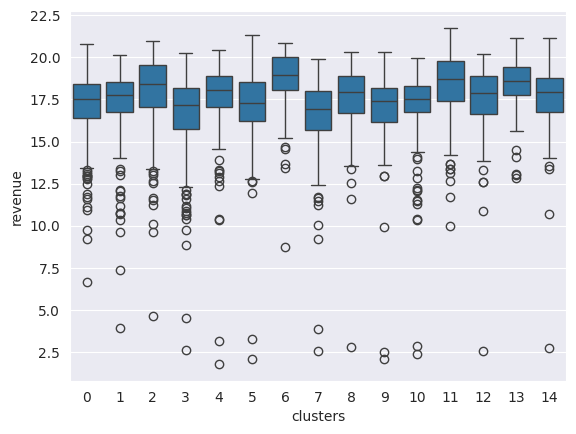

In [209]:
sns.set_style('darkgrid')
sns.boxplot(x='clusters',y='revenue',data=master_df)

In [210]:
tmdb_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3270 entries, 0 to 4798
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   budget                  3270 non-null   float64
 1   genres                  3270 non-null   object 
 2   id                      3270 non-null   int64  
 3   keywords                3270 non-null   object 
 4   popularity              3270 non-null   float64
 5   release_date            3270 non-null   object 
 6   revenue                 3270 non-null   float64
 7   runtime                 3270 non-null   float64
 8   title                   3270 non-null   object 
 9   vote_average            3270 non-null   float64
 10  vote_count              3270 non-null   float64
 11  keyword_strength        3270 non-null   float64
 12  release_year            3270 non-null   float64
 13  genres_list             3270 non-null   object 
 14  genre_revenue_strength  3270 non-null   float

In [211]:
COLUMNS_TO_USE = [
    'title',
    'budget',
    'revenue',
    'genre_revenue_strength',
    'keyword_strength',
    'clusters',
    'genres_list',
    'keywords',
    'popularity',
    'release_date',
    'release_year', 'action', 'adventure', 'animation', 'comedy', 'crime', 'documentary',
    'drama', 'family', 'fantasy', 'foreign', 'history', 'horror', 'music',
    'mystery', 'romance', 'science_fiction', 'thriller', 'war', 'western'
]

# Adding .copy() creates a new object and prevents SettingWithCopyWarning
master_df = master_df[COLUMNS_TO_USE].copy()

In [212]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3270 entries, 0 to 4798
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   3270 non-null   object 
 1   budget                  3270 non-null   float64
 2   revenue                 3270 non-null   float64
 3   genre_revenue_strength  3270 non-null   float64
 4   keyword_strength        3270 non-null   float64
 5   clusters                3270 non-null   int32  
 6   genres_list             3270 non-null   object 
 7   keywords                3270 non-null   object 
 8   popularity              3270 non-null   float64
 9   release_date            3270 non-null   object 
 10  release_year            3270 non-null   float64
 11  action                  3270 non-null   int64  
 12  adventure               3270 non-null   int64  
 13  animation               3270 non-null   int64  
 14  comedy                  3270 non-null   int64

In [213]:
master_df['crowd'] = master_df['revenue'] / 5.5 # 5.5 dolars

In [214]:
def transform_datetime(master_df:pd.DataFrame,time_col:str):
  master_df[time_col] = pd.to_datetime(master_df[time_col], errors='coerce')
  master_df['month'] = master_df[time_col].dt.month
  master_df['week_release'] = master_df[time_col].dt.isocalendar().week
  # Corrected: calculate day of week from the actual datetime column
  master_df['realease_day_of_week'] = master_df[time_col].dt.dayofweek

  return master_df

In [215]:
# Re-run crowd calculation without warnings
master_df['crowd'] = master_df['revenue'] / 5.5

# Apply the corrected datetime transformation function
master_df = transform_datetime(master_df, 'release_date')

print("Transformations complete. Updated columns:")
print(master_df.columns)
display(master_df[['release_date', 'month', 'week_release', 'realease_day_of_week']].head())

Transformations complete. Updated columns:
Index(['title', 'budget', 'revenue', 'genre_revenue_strength',
       'keyword_strength', 'clusters', 'genres_list', 'keywords', 'popularity',
       'release_date', 'release_year', 'action', 'adventure', 'animation',
       'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy',
       'foreign', 'history', 'horror', 'music', 'mystery', 'romance',
       'science_fiction', 'thriller', 'war', 'western', 'crowd', 'month',
       'week_release', 'realease_day_of_week'],
      dtype='object')


,release_date,month,week_release,realease_day_of_week
0,2009-12-10,12,50,3
1,2007-05-19,5,20,5
2,2015-10-26,10,44,0
3,2012-07-16,7,29,0
4,2012-03-07,3,10,2


Standard Box Office Decay Model

Most movies follow exponential decay:

Wt=W1×e−λt
W
t
	​

=W
1
	​

×e
−λt

Where:

W1
W
1
	​

 = opening week crowd

t
t = week number

λ
λ = decay rate

In [216]:
master_df.head(1)

,title,budget,revenue,genre_revenue_strength,keyword_strength,clusters,genres_list,keywords,popularity,release_date,...,mystery,romance,science_fiction,thriller,war,western,crowd,month,week_release,realease_day_of_week
0,Avatar,19.283571,21.748578,1.739210e+08,20.180652,11,"[action, adventure, fantasy, science_fiction]","[culture clash, future, space war, space colon...",150.437577,2009-12-10,...,0,0,1,0,0,0,3.954287,12,50,3


In [217]:
master_df['crowd_real'] = np.expm1(master_df['crowd']) # convert from log1p

In [218]:
cluster_total_crowd = master_df.groupby('clusters')['crowd_real'].mean()
cluster_total_crowd

,crowd_real
clusters,
0,22.981141
1,23.474466
2,27.107408
3,21.152128
4,25.090050
5,22.718147
6,30.527538
7,20.552371
8,24.895976


In [219]:
COLUMNS_TO_TRAIN = [
  'budget',
  'clusters',
  'release_year',
  'crowd',
  'action',
  'realease_day_of_week',
  'week_release',
  'month',
  'crime',
  'animation',
  'adventure',
  'comedy',
  'documentary',
  'drama',
  'family',
  'fantasy',
  'foreign',
  'history',
  'horror',
  'music',
  'mystery',
  'romance',
  'science_fiction',
  'thriller',
  'war',
  'western'
]


In [220]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Split by year
train_df = master_df[master_df['release_year'] <= 2013]
test_df = master_df[master_df['release_year'] > 2013]

# Fix: Explicitly use COLUMNS_TO_TRAIN and ensure 'crowd' is target
# We must remove 'crowd' from the input features X
features = [col for col in COLUMNS_TO_TRAIN if col != 'crowd']

x_train = train_df[features]
y_train = train_df['crowd']

x_test = test_df[features]
y_test = test_df['crowd']

print(f"Training features: {x_train.columns.tolist()}")
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Training features: ['budget', 'clusters', 'release_year', 'action', 'realease_day_of_week', 'week_release', 'month', 'crime', 'animation', 'adventure', 'comedy', 'documentary', 'drama', 'family', 'fantasy', 'foreign', 'history', 'horror', 'music', 'mystery', 'romance', 'science_fiction', 'thriller', 'war', 'western']
Train shape: (2934, 25), Test shape: (336, 25)


In [221]:
# optuna session for chosing the best model

def objective_random(trial):

    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 3, 25),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )

    model.fit(x_train, y_train)

    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)

    return mae


In [222]:
study_random = optuna.create_study(direction='minimize')
study_random.optimize(objective_random, n_trials=30)

[I 2026-02-26 20:14:39,408] A new study created in memory with name: no-name-eba92bb4-f301-4475-8ee0-f05f71e8bc94
[I 2026-02-26 20:14:46,447] Trial 0 finished with value: 0.19701984901936048 and parameters: {'n_estimators': 748, 'max_depth': 3, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 0.6719459383036619}. Best is trial 0 with value: 0.19701984901936048.
[I 2026-02-26 20:14:55,167] Trial 1 finished with value: 0.18673442212422495 and parameters: {'n_estimators': 428, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.9016282509175522}. Best is trial 1 with value: 0.18673442212422495.
[I 2026-02-26 20:15:00,259] Trial 2 finished with value: 0.1859226952679259 and parameters: {'n_estimators': 637, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_features': 0.3269011193058821}. Best is trial 2 with value: 0.1859226952679259.
[I 2026-02-26 20:15:02,594] Trial 3 finished with value: 0.18986275824411009 and parameters:

In [223]:
print(study_random.best_params)

{'n_estimators': 310, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.5297269156745985}


In [224]:
# Initialize the model with the best parameters found by Optuna
best_model_forest = RandomForestRegressor(**study_random.best_params, random_state=42)

# Fit the optimized model to the training data
best_model_forest.fit(x_train,y_train)

# Generate new predictions
pred_log = best_model_forest.predict(x_test)
pred_total = np.expm1(pred_log)


In [225]:
import joblib

joblib.dump(best_model_forest,'best_model_attendance.pkl')

['best_model_attendance.pkl']

In [226]:
print(f'MAE : {mean_absolute_error(y_test,pred_log)}')
print(f'MSE : {mean_squared_error(y_test,pred_log)}')
print(f'R2 : {r2_score(y_test,pred_log)}')

MAE : 0.1825048633812792
MSE : 0.06335494445086012
R2 : 0.47261354933978905




MAE : 0.18304143642135998
MSE : 0.06282557186584793
R2 : 0.4770202129570691
--- Good metrics for attendance prediction --- (log_scale)

In [227]:
def simulate_week_crowd(total_crowd, decay=0.45, weeks=5):
    """
    Takes a total crowd figure and distributes it over X weeks
    using an exponential decay model.
    """
    # weight decay for the weeks
    weights = np.array([
        np.exp(-decay * i)
        for i in range(weeks)
    ])

    # Normalize weights so they sum to 1
    weights = weights / weights.sum()

    # Calculate weekly crowd
    weekly = total_crowd * weights

    return weekly.tolist()



In [228]:
master_df['weekly_sim'] = master_df['crowd_real'].apply(
    lambda x : simulate_week_crowd(x)
)

master_df[['title','weekly_sim','crowd_real']]

weekly_df = master_df.explode('weekly_sim').copy()


In [229]:
# Simulate Movie_A
movie_a = {
    "title": "Movie_A",
    "budget": 50.0,
    "revenue": 0,
    "genre_revenue_strength": 1.2,
    "keyword_strength": 2.0,
    "clusters": 6,
    "genres_list": ["action", "adventure"],
    "keywords": ["hero", "quest"],
    "popularity": 75.0,
    "release_date": pd.to_datetime("2026-03-01"),
    "release_year": 2026,
    "action": 1,
    "adventure": 1,
    "animation": 0,
    "comedy": 0,
    "crime": 0,
    "documentary": 0,
    "drama": 0,
    "family": 0,
    "fantasy": 0,
    "foreign": 0,
    "history": 0,
    "horror": 0,
    "music": 0,
    "mystery": 0,
    "romance": 0,
    "science_fiction": 0,
    "thriller": 0,
    "war": 0,
    "western": 0,
    "month": 3,
    "week_release": 9,
    "realease_day_of_week": 1
}


In [230]:
# SIMULATING MOVIE THEATERS BY REGION

def movieTheaters(NUM_CINEMAS=85) -> pd.DataFrame:

  SEATS_STRUCTURE = [225,225,160,160,80,80,80,80]
  cinemas = []

  for i in range(NUM_CINEMAS):
    if i < 21:
      region = 'North'
    elif i < 42:
      region = 'South'
    elif i < 63:
      region = 'East'
    else:
      region = 'West'

    for r,cap in enumerate(SEATS_STRUCTURE,start=1):
      cinemas.append({
          'cinema_id' : i+1,
          'room_id' : f'Room_{r}',
          'region' : region,
          'capacity':cap
      })

  cinemas_df = pd.DataFrame(cinemas)
  return cinemas_df

def simulate_week_crowd(total_crowd, decay=0.45, weeks=5):
    """
    Takes a total crowd figure and distributes it over X weeks
    using an exponential decay model.
    """
    # weight decay for the weeks
    weights = np.array([
        np.exp(-decay * i)
        for i in range(weeks)
    ])

    # Normalize weights so they sum to 1
    weights = weights / weights.sum()

    # Calculate weekly crowd
    weekly = total_crowd * weights

    return weekly.tolist()


def showtime_decay(n_slots, peak_index=2, sharpness=1.2):
    """
    Generates behavioral weights for showtimes.

    n_slots: number of showtimes in the day
    peak_index: which slot is peak (e.g., 20:00)
    sharpness: how concentrated demand is around peak
    """

    indices = np.arange(n_slots)

    weights = np.exp(-sharpness * (indices - peak_index) ** 2)

    weights = weights / weights.sum()

    return weights.tolist()

def showtime_clusters(clusters,n_slots=24):
  pass

In [231]:
cinema_df = movieTheaters(NUM_CINEMAS=85)

In [232]:
model = joblib.load('best_model_attendance.pkl')

features_cols = [col for col in COLUMNS_TO_TRAIN if col != 'crowd']

X_new = pd.DataFrame([movie_a])[features_cols]

predicted_log = model.predict(X_new)
predicted_total = np.expm1(predicted_log)

print("New prediction",predicted_total)

New prediction [36.24999017]


In [239]:
new_movies = [
    {
        "title": "Movie_A",
        "budget": 50.0,
        "clusters": 6,
        "release_year": 2026,
        "month": 3,
        "week_release": 9,
        "realease_day_of_week": 4,
        "release_date": pd.to_datetime("2026-04-11"),
        "action": 1,
        "adventure": 1,
        "comedy": 0,
        "drama": 0,
        "thriller": 0,
        "science_fiction": 0,
        "animation": 0,
        "family": 0,
        "fantasy": 0,
        "crime": 0,
        "documentary": 0,
        "foreign": 0,
        "history": 0,
        "horror": 0,
        "music": 0,
        "mystery": 0,
        "romance": 0,
        "war": 0,
        "western": 0,
    },

    {
        "title": "Movie_B",
        "budget": 12.0,
        "clusters": 7,
        "release_year": 2026,
        "month": 3,
        "week_release": 9,
        "realease_day_of_week": 4,
        "release_date": pd.to_datetime("2026-12-16"),
        "action": 0,
        "adventure": 0,
        "comedy": 1,
        "drama": 1,
        "thriller": 0,
        "science_fiction": 0,
        "animation": 0,
        "family": 0,
        "fantasy": 0,
        "crime": 0,
        "documentary": 0,
        "foreign": 0,
        "history": 0,
        "horror": 0,
        "music": 0,
        "mystery": 0,
        "romance": 1,
        "war": 0,
        "western": 0,
    }
]

In [240]:
def simulate_full_schedule(movie_list, cinema_df):
  """
  att is for attendance
  """

  # showtime weights decay parameters with Gaussian modeling
  peak_index=2
  sharpness=1.2
  rows = []

  model = joblib.load('best_model_attendance.pkl')

  features_cols = [col for col in COLUMNS_TO_TRAIN if col != 'crowd']

  # Calculate time decay weights once
  SHOWTIMES = ["14:00","16:00","17:00","17:30","20:00","21:00","22:30"]
  time_decay_weights = np.array(showtime_decay(len(SHOWTIMES), peak_index, sharpness))

  # Pre-calculate region weights
  region_capacity = cinema_df.groupby('region')['capacity'].sum()
  total_capacity = cinema_df["capacity"].sum()
  regions_weights = region_capacity / total_capacity


  for movie_idx, movie_data in enumerate(movie_list): # Iterate over each movie separately
    X_new_single_movie = pd.DataFrame([movie_data])[features_cols]

    predicted_log_single = model.predict(X_new_single_movie)
    predicted_total_single = np.expm1(predicted_log_single)[0] # Extract the scalar prediction

    movie_data['predicted_total'] = predicted_total_single # Assign scalar prediction to movie_data
    print(f"Crowd prediction for the movie {movie_data['title']} : {movie_data['predicted_total']}")

    weekly_values = simulate_week_crowd(predicted_total_single, 0.45, 5) # Now total_crowd is a scalar

    # Convert release_date to datetime object once per movie
    release_date_dt = pd.to_datetime(movie_data['release_date'])


    for week_idx, week_att in enumerate(weekly_values):
      for region in regions_weights.index:
        region_att = week_att * regions_weights[region]
        region_df = cinema_df[cinema_df['region'] == region]

        # Ensure 'cinema_id' is used for grouping
        cinema_capacity_in_region = region_df.groupby('cinema_id')['capacity'].sum()
        if cinema_capacity_in_region.empty:
            continue

        cinema_weights = cinema_capacity_in_region / cinema_capacity_in_region.sum()

        for cinema_id_val in cinema_weights.index: # Iterate by actual cinema_id
          cinema_att = region_att * cinema_weights[cinema_id_val]
          cinema_rooms = region_df[region_df['cinema_id'] == cinema_id_val] # Filter by cinema_id

          # Using .iterrows() is fine here for processing each room
          rooms_weights = cinema_rooms['capacity'] / cinema_rooms['capacity'].sum()


          for room_original_idx, room_row in cinema_rooms.iterrows(): # room_row is a Series now
            room_att_week = cinema_att * rooms_weights.loc[room_row.name] # Access by original index for weight

            for day in range(8): # Assuming 8 days in a "week" for distribution
              day_att = room_att_week / 8

              for time_idx, time_str in enumerate(SHOWTIMES):
                show_att = day_att * time_decay_weights[time_idx] # Use pre-calculated time decay weights
                show_att = min(show_att, room_row['capacity']) # safe measure (realistic)

                percent_capacity = (show_att / room_row['capacity']) * 100 if room_row['capacity'] > 0 else 0

                # Combine date and time correctly
                current_date = release_date_dt + pd.Timedelta(weeks=week_idx, days=day)
                # Ensure the time part is correctly added
                current_datetime = current_date.replace(hour=int(time_str.split(':')[0]), minute=int(time_str.split(':')[1]))

                rows.append({
                                  "title": movie_data["title"], # Reference movie_data
                                  "region": room_row["region"], # Get region from room_row
                                  "cinema": room_row["cinema_id"], # Use cinema_id from room_row
                                  "room": room_row["room_id"],     # Use room_id from room_row
                                  "week": week_idx + 1,
                                  "datetime": current_datetime,
                                  "capacity": room_row["capacity"],
                                  "attendance": show_att,
                                  "percent_capacity": percent_capacity
                })
  return pd.DataFrame(rows)

In [241]:
final_df = simulate_full_schedule(new_movies,cinema_df)

Crowd prediction for the movie Movie_A : 37.00628376911242
Crowd prediction for the movie Movie_B : 13.861163240748988


In [242]:
final_df.head()

,title,region,cinema,room,week,datetime,capacity,attendance,percent_capacity
0,Movie_A,East,43,Room_1,1,2026-04-11 14:00:00,225,0.000023,0.000010
1,Movie_A,East,43,Room_1,1,2026-04-11 16:00:00,225,0.000847,0.000376
2,Movie_A,East,43,Room_1,1,2026-04-11 17:00:00,225,0.002811,0.001249
3,Movie_A,East,43,Room_1,1,2026-04-11 17:30:00,225,0.000847,0.000376
4,Movie_A,East,43,Room_1,1,2026-04-11 20:00:00,225,0.000023,0.000010
